In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
df = pd.read_csv('/content/Telco_Customer_Churn_Cleaned.csv')

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [3]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

Accuracy: 0.8045486851457001


In [4]:
precision = precision_score(
    y_test,
    y_pred
)

print("Precision:",precision)

Precision: 0.6486486486486487


In [5]:
recall = recall_score(
    y_test,
    y_pred
)

print("Recall:",recall)

Recall: 0.5775401069518716


In [6]:
f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:",f1)

F1 Score: 0.611032531824611


In [7]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.58      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



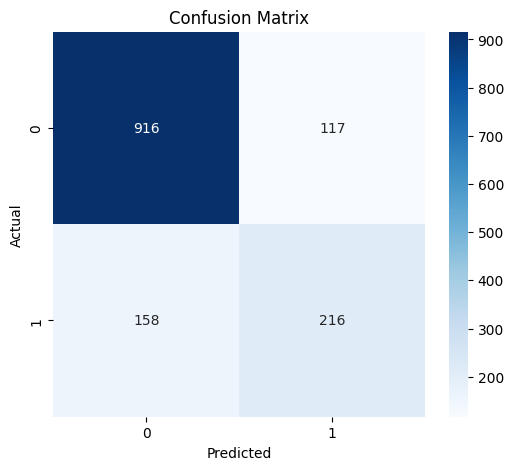

In [8]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [9]:
y_prob = model.predict_proba(
    X_test
)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:",roc_auc)

ROC-AUC: 0.8361594131624313


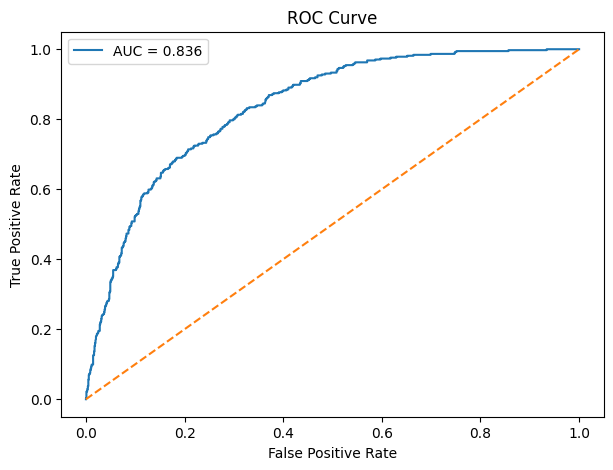

In [10]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()